In [1]:
import numpy as np
from matplotlib import pyplot as plt 
import time 
from tqdm import tqdm

import jax
import jax.numpy as jnp
    
from dataclasses import dataclass
#jax.config.update("jax_disable_jit", True)

import pickle

import nambu_class as nmb
import system_state as sys_state
import run_computation as comp
import custom_optimizer as copt
import Usadel_methods as usadel


#jax.config.update("jax_disable_jit", True)


In [2]:
import numpy as np 

def run_full_scan(temp, phonon_scattering, eta, filename = None,  current_amplitudes = np.linspace(0.2, 6, 20), tc_rescaling = 1.0):

    if filename is None:
        filename = 'Quasi-static-evolution-T:' + str(np.round(temp,2)) + ' phonons:' + str(np.round(phonon_scattering,3)) + ' eta:' + str(np.round(eta,3)) + '-2' + '.pkl'

    temp = temp * tc_rescaling

    data_out = {}

    cutoff = 30 * usadel.UsadelEvolution.get_bcs_ratio()
    nw = 1500

    grid_parameters = {'omega_sampling': nw, 'cutoff': cutoff, 'time_duration': 5.0, 'time_sampling': 100}
    system_parameters = {'critical_temperature': 1.0, 'current_maximum': 1.0, 'temperature': temp, 'z_t/R_n': 50/150, 'eta': eta}
    optimization_parameters = {'custom_jac': False, 'tol': 1e-3, 'maxiter': 50}
    sigma_scatterings = {'Phonon': phonon_scattering} # {'Dynes': 0.0, 'Elastic': 0.0}

    my_usadel = usadel.UsadelEvolution(grid_parameters, system_parameters, sigma_scatterings)

    #temp_list = jnp.linspace(0, 1.2, 30)
    #Q_list = jnp.linspace(0.0,0.7,1)
    #gap_list, current_list = comp.calculate_equilibrium(temp_list, grid_parameters, system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = sigma_scatterings,  Q_list = Q_list)

    #T_c_scaling = temp_list[jnp.where(gap_list[:,0] > 0.05)][-1]
    
    #data_out['t_scan_T_c_scaling'] = T_c_scaling
    #data_out['t_scan_gaps'] = gap_list

    # do the q_scan    
    temp_list = jnp.linspace(temp, 1.2, 1)
    Q_list = jnp.linspace(0.0,0.7,30)

    gap_list, current_list = comp.calculate_equilibrium(temp_list, grid_parameters, system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = sigma_scatterings,  Q_list = Q_list)
    data_out['q_scan_gaps'] = gap_list
    data_out['q_scan_currents'] = current_list

    plt.plot(Q_list, current_list[0].real)
    plt.show()

    CURRENT_MAXIMUM = jnp.max(current_list[0])

    data_out['q_scan_current_max'] = CURRENT_MAXIMUM

    grid_parameters = {'omega_sampling': nw, 'cutoff': cutoff, 'time_duration': 1.0, 'time_sampling': 100}
    system_parameters = {'critical_temperature': 1.0, 'current_maximum': CURRENT_MAXIMUM, 'temperature': temp, 'z_t/R_n': 50/150, 'eta': eta}
    optimization_parameters = {'custom_jac': False, 'tol': 1e-3, 'maxiter': 50}
    sigma_scatterings = {'Phonon': phonon_scattering} # {'Dynes': 0.0, 'Elastic': 0.0}
    #sigma_scatterings = None
    
    run_temperature = temp

    T_c = 15.5 / tc_rescaling

    t_pulse = 0.020 * T_c

    current_function_gaussian = lambda t: np.exp(-(t - 0)**2 * np.log(2)/(t_pulse)**2) 
    current_function_lorenzian = lambda t: t_pulse**2/((t)**2 + t_pulse**2)
    
    times_out = []
    pulse_in_out = []
    current_vs_time_out = []
    gap_vs_time_out = []
    q_vs_time_out = []
    transmitivity_out = []
    current_inside_out = []

    for amp in current_amplitudes:
        crt_pulse = lambda x: amp * current_function_lorenzian(x)
        times, pulse_in, current_vs_time, gap_vs_time, q_vs_time = comp.real_time_evolve(run_temperature, current_function=crt_pulse, grid_parameters = grid_parameters, system_parameters = system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = sigma_scatterings)
        times_out += [times]
        pulse_in_out += [pulse_in]
        current_vs_time_out += [current_vs_time]
        gap_vs_time_out += [gap_vs_time]
        q_vs_time_out += [q_vs_time]
        transmitivity_out += [jnp.max(current_vs_time)/jnp.max(pulse_in)]
        current_inside_out += [jnp.max(current_vs_time)]

    data_out['times'] = times_out
    data_out['pulse_in'] = pulse_in_out
    data_out['current_vs_time'] = current_vs_time_out
    data_out['gap_vs_time'] = gap_vs_time_out
    data_out['q_vs_time'] = q_vs_time_out
    data_out['transmitivity'] = transmitivity_out
    data_out['current_inside'] = current_inside_out
    
    #with open(filename, 'wb') as output:  # Overwrites any existing file.
    #    pickle.dump(data_out, output)

    return data_out

In [3]:
def linear_circuit_response(times, current_function, parameters):

    current_values = current_function(times)

    impedance = lambda omega: 1j * omega  / parameters['z_t/R_n']/ parameters['gap']/ np.pi + 1/ parameters['z_t/R_c']
    transmission_coefficient = lambda omega : 2 / (2 + impedance(omega))
    #transmission_coefficient = lambda omega: 1

    # NOTE: FFT is naturally done in frequency space
    current_fft = np.fft.fft(current_values)
    frequencies = np.fft.fftfreq(np.size(current_values),times[1] - times[0]) 

    current_trans = current_fft * transmission_coefficient(frequencies * 2 * np.pi)
    voltage = current_trans * impedance(frequencies * 2 * np.pi)

    return frequencies * 2 * np.pi,current_fft,np.fft.ifft(current_trans),np.fft.ifft(voltage)


def compute_coherence_length(critical_current, r_n, max_current, gap_0):
    kbtc_over_e =  1.33 #(mV)
    # crtic_current in mA
    # return is in nm 
    return kbtc_over_e / r_n * max_current / critical_current * 30e-3 /jnp.sqrt(gap_0)# 


### Test Gap BCS ratio for no phonon scattering and small eta

In [4]:
cutoff = 30 * usadel.UsadelEvolution.get_bcs_ratio()
nw = 1000
temp = 0.5, 
phonon_scattering = 0.0
eta = 0.05

grid_parameters = {'omega_sampling': nw, 'cutoff': cutoff, 'time_duration': 5.0, 'time_sampling': 100}
system_parameters = {'critical_temperature': 1.0, 'current_maximum': 1.0, 'temperature': temp, 'z_t/R_n': 50/150, 'eta': eta}
optimization_parameters = {'custom_jac': False, 'tol': 1e-3, 'maxiter': 50}
sigma_scatterings = {'Phonon': phonon_scattering} # {'Dynes': 0.0, 'Elastic': 0.0}
sigma_scatterings = None

my_usadel = usadel.UsadelEvolution(grid_parameters, system_parameters, sigma_scatterings)

In [12]:
temp_list = jnp.linspace(0.01, 1.2, 20)
Q_list = jnp.linspace(0.0,0.7,1)
gap_list, current_list = comp.calculate_equilibrium(temp_list, grid_parameters, system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = sigma_scatterings,  Q_list = Q_list)

T_c_scaling = temp_list[jnp.where(gap_list[:,0] > 0.05)][-1]

# do the q_scan    

  0%|          | 0/1 [00:09<?, ?it/s]


KeyboardInterrupt: 

1.6589123


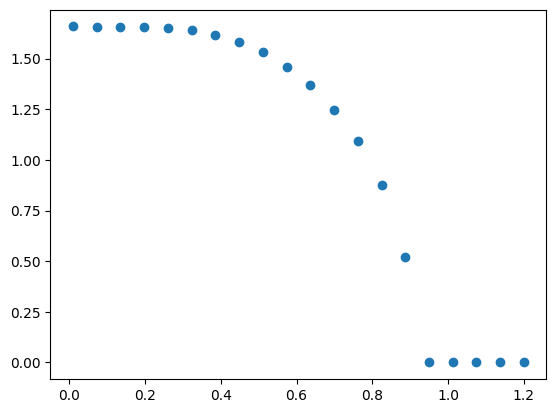

In [ ]:
plt.scatter(temp_list,gap_list[:,0])
print(jnp.max(gap_list[:,0]))

### Checking current code and reflectivity code by making sure linear response above $T_C$ matches the normal state resistivity

In [ ]:
cutoff = 30 * usadel.UsadelEvolution.get_bcs_ratio()
nw = 1000

# Define the fine grid
fine_nw = 200
fine_cutoff = 1.0* usadel.UsadelEvolution.get_bcs_ratio()

fine_nw = nw
fine_cutoff = cutoff

grid_parameters = {'omega_sampling': nw, 'cutoff': cutoff, 'time_duration': 1.0, 'time_sampling': 100}
system_parameters = {'critical_temperature': 1.0, 'current_maximum': 1.0, 'temperature': 0.5, 'z_t/R_n': 50/170}
optimization_parameters = {'custom_jac': False, 'tol': 1e-3, 'maxiter': 100}
sigma_scatterings = {'Phonon': 0.1} # {'Dynes': 0.0, 'Elastic': 0.0}
sigma_scatterings = None

run_temperature = 1.5

#* T_c in kelvin
T_c = 15.5 
#* write the current pulse in units of T_C. 
#*  FWHM = 1ps in 
t_pulse = 0.020 * T_c * 2 * jnp.pi
print('T pulse is ', t_pulse)
current_function_gaussian = lambda t: np.exp(-(t - 0)**2 * np.log(2)/(t_pulse)**2) 

T pulse is  0.31


In [ ]:
crt_pulse = lambda x: 0.1 * current_function_gaussian(x)
times, pulse_in, current_vs_time, gap_vs_time, q_vs_time = comp.real_time_evolve(run_temperature, current_function=crt_pulse, grid_parameters = grid_parameters, system_parameters = system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = sigma_scatterings)

100%|██████████| 99/99 [05:56<00:00,  3.60s/it] 


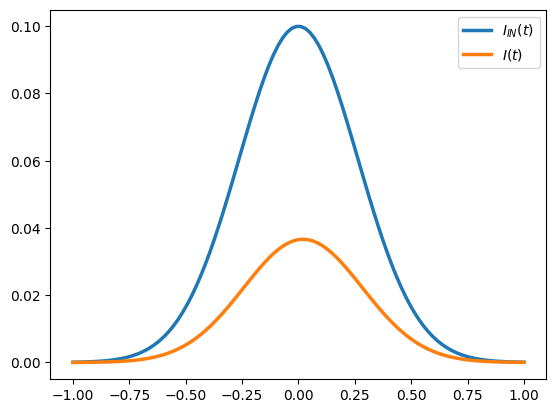

Transmitivity is 0.36647585
Theoretical_transmitivity is 0.37037037037037035


In [ ]:
plt.plot(times , pulse_in, label = r'$I_{IN}(t)$', linewidth = 2.5) 
plt.plot(times, current_vs_time, label = r'$I(t)$', linewidth = 2.5)
plt.legend()
plt.show()

crt_pulse = lambda x: 0.1 * current_function_gaussian(x)
print('Transmitivity is', jnp.max(current_vs_time)/jnp.max(pulse_in))
print('Theoretical_transmitivity is', 2/(2 + 1/system_parameters['z_t/R_n']))

### Checking current code by making sure linear response matches the superfluid density, also check $2\pi$ factors in frequencies

In [ ]:
cutoff = 30 * usadel.UsadelEvolution.get_bcs_ratio()
nw = 1500
temp = 0.1, 
phonon_scattering = 0.0
eta = 0.05

grid_parameters = {'omega_sampling': nw, 'cutoff': cutoff, 'time_duration': 1.2, 'time_sampling': 200}
system_parameters = {'critical_temperature': 1.0, 'current_maximum': 1.0, 'temperature': temp, 'z_t/R_n': 50/170, 'eta': eta}
optimization_parameters = {'custom_jac': False, 'tol': 1e-3, 'maxiter': 50}
sigma_scatterings = {'Phonon': phonon_scattering} # {'Dynes': 0.0, 'Elastic': 0.0}
sigma_scatterings = None

my_usadel = usadel.UsadelEvolution(grid_parameters, system_parameters, sigma_scatterings)

run_temperature = temp

#* T_c in kelvin
T_c = 15.5 
#* write the current pulse in units of T_C. 
#*  FWHM = 1ps in 
t_pulse = 0.0208 * T_c #* 2 * jnp.pi  #! should be times 2pi since we used hbar = 1 
print('T pulse is ', t_pulse)
current_function_gaussian = lambda t: np.exp(-(t - 0)**2 * np.log(2)/(t_pulse)**2) 

T pulse is  0.32239999999999996


In [ ]:
temp_list = jnp.linspace(0.1, 1.2, 1)
Q_list = jnp.linspace(0.0,0.3,10)

gap_list, current_list = comp.calculate_equilibrium(temp_list, grid_parameters, system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = sigma_scatterings,  Q_list = Q_list)


100%|██████████| 10/10 [03:19<00:00, 20.00s/it]


[1.6765039 1.6759993 1.6739299 1.6706355 1.6659572 1.6599845 1.6526027
 1.6435901 1.6315935 1.6232605]


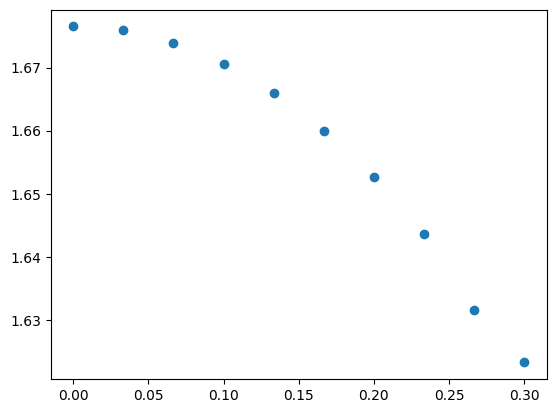

[0.         0.16980152 0.33883035 0.5069142  0.67326766 0.8374221
 0.9986619  1.155742   1.303918   1.4638642 ]


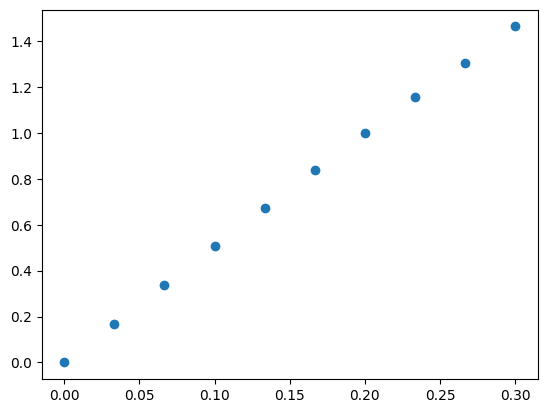

MAXIMUM CURRENT IS 1.4638642
linear proprotionality is 5.094045
rough linear proprotionality theory is 5.2668924


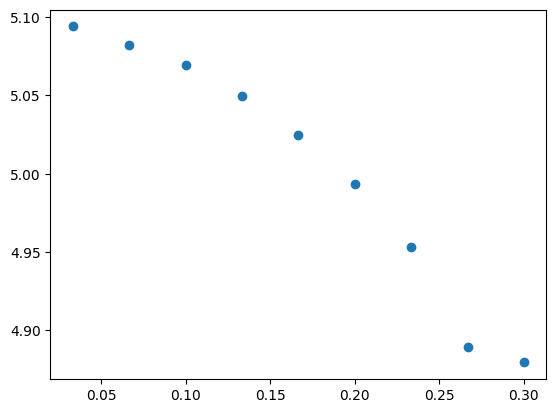

In [ ]:

#print(gap_list)
#plt.scatter(temp_list,gap_list)
plt.scatter(Q_list,gap_list.T)
print(gap_list[0])
plt.show()
print(current_list[0])
plt.scatter(Q_list,current_list[0].real)
plt.show()
plt.scatter(Q_list,current_list[0].real/Q_list)
#plt.plot(Q_list,np.abs(gap_list.T[0])* (1 - Q_list**2/gap_list.T[0]/2) ** (3/2), 'k--')

CURRENT_MAXIMUM = jnp.max(current_list[0])

print('MAXIMUM CURRENT IS', CURRENT_MAXIMUM)

print('linear proprotionality is', jnp.max((current_list[0].real/Q_list)[1:]))
print('rough linear proprotionality theory is', jnp.max(gap_list) * jnp.pi)

In [ ]:
system_parameters = {'critical_temperature': 1.0, 'current_maximum': 1.4638642, 'temperature': temp, 'z_t/R_n': 50/170, 'eta': eta}

crt_pulse = lambda x: 0.1 * current_function_gaussian(x)

times, pulse_in, current_vs_time, gap_vs_time, q_vs_time = comp.real_time_evolve(0.1, current_function=crt_pulse, grid_parameters = grid_parameters, system_parameters = system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = sigma_scatterings)

100%|██████████| 199/199 [15:39<00:00,  4.72s/it]


In [ ]:
times_fft = np.linspace(-10, 10, 10000)

fft_params = {'gap': 5.094045/np.pi, 'z_t/R_n': 50/170, 'z_t/R_c': 10000}
frequencies, current_fft, current_trans, linear_voltage = linear_circuit_response( times = times_fft, parameters = fft_params, current_function = crt_pulse)


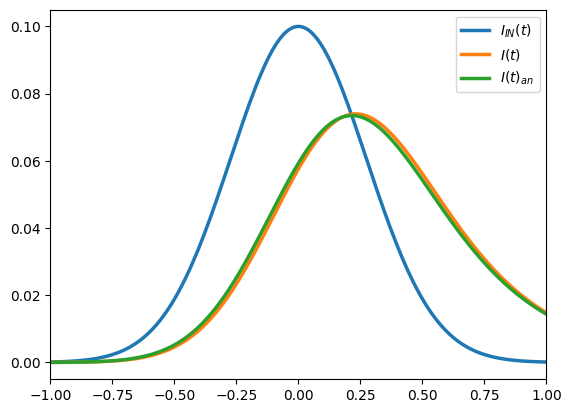

Transmitivity is 0.7397157
Linear response transmitivity is (0.73488027-8.063109e-17j)


In [ ]:
plt.plot(times , pulse_in, label = r'$I_{IN}(t)$', linewidth = 2.5) 
plt.plot(times, current_vs_time, label = r'$I(t)$', linewidth = 2.5)
plt.plot(times_fft, np.real(current_trans), label = r'$I(t)_{an}$', linewidth = 2.5)
plt.xlim(-1,1)
plt.legend()
plt.show()
print('Transmitivity is', jnp.max(current_vs_time)/jnp.max(pulse_in))
print('Linear response transmitivity is', jnp.max(current_trans)/jnp.max(pulse_in))


### Checking $\Sigma^{ph, (R)}_{\epsilon}$ by computing phonon scattering near $T_c$, i.e. $\Delta \ll T$

In [4]:
from self_energy_class import PhononScattering
cutoff = 30 * usadel.UsadelEvolution.get_bcs_ratio()
nw = 1000

# Define the fine grid
fine_nw = 200
fine_cutoff = 1.0* usadel.UsadelEvolution.get_bcs_ratio()

fine_nw = nw
fine_cutoff = cutoff

grid_parameters = {'omega_sampling': nw, 'cutoff': cutoff, 'time_duration': 1.0, 'time_sampling': 100}
system_parameters = {'critical_temperature': 1.0, 'current_maximum': 1.0, 'temperature': 0.4, 'z_t/R_n': 50/170, 'eta': 0.01}
optimization_parameters = {'custom_jac': False, 'tol': 1e-3, 'maxiter': 100}
sigma_scatterings = {'Phonon': 0.00} # {'Dynes': 0.0, 'Elastic': 0.0}
#sigma_scatterings = None

run_temperature = 1.0

#* T_c in kelvin
T_c = 15.5 
#* write the current pulse in units of T_C. 
#*  FWHM = 1ps in 
t_pulse = 0.020 * T_c * 2 * jnp.pi
print('T pulse is ', t_pulse)
current_function_gaussian = lambda t: np.exp(-(t - 0)**2 * np.log(2)/(t_pulse)**2) 

my_usadel = usadel.UsadelEvolution(grid_parameters = grid_parameters, system_parameters = system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = sigma_scatterings)
print('Dynes eta is', my_usadel.eta)
omega_grid = my_usadel.w_arr

T pulse is  1.9477874452256718
Dynes eta is 0.062916316


In [5]:
temp_list = jnp.linspace(1.2, 1.3, 1)
Q_list = jnp.linspace(0.0,0.3,1)

gap_list, current_list, g_list = comp.calculate_equilibrium_full(temp_list, grid_parameters, system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = sigma_scatterings,  Q_list = Q_list)


100%|██████████| 1/1 [00:01<00:00,  1.23s/it]


In [6]:
crt_gr =  g_list[0]
crt_gap = gap_list[0]
print('gap is', crt_gap)
crt_f = nmb.NambuTensor(my_usadel._thermal_occupation_numbers(1.0),0)

gap2 = my_usadel._calc_gap(crt_gr, crt_f)
print('gap2 is', gap2)

crt_sigma = PhononScattering(scattering_rate= 1.0, omega_arr= omega_grid, temperature = 1.0)

gap is [3.9943564e-13]
gap2 is (4.208748e-13-0j)


In [9]:
scattering_sigma = crt_sigma._sigma_r(crt_gr, crt_f)

In [10]:
crt_gk = crt_gr @ crt_f + crt_f @ crt_gr._involution()
kernel1 = omega_grid**2/(jnp.tanh(jnp.abs(omega_grid)/2/1.0 + 1e-4))
kernel2 = (omega_grid**2 * jnp.sign(omega_grid))

deps = jnp.diff(omega_grid,prepend= omega_grid[0])

print(deps)

[0.         0.10594177 0.10593414 0.10594177 0.10593414 0.10594177
 0.10593414 0.10594177 0.10594177 0.10593414 0.10594177 0.10593414
 0.10594177 0.10593796 0.10593796 0.10594177 0.10593414 0.10594177
 0.10593414 0.10594177 0.10593796 0.10593796 0.10594177 0.10593414
 0.10594177 0.10593414 0.10594177 0.10593796 0.10593796 0.10594177
 0.10593414 0.10594177 0.10593796 0.10593796 0.10593796 0.10593796
 0.10594177 0.10593414 0.10594177 0.10593796 0.10593796 0.10593796
 0.10593796 0.10594177 0.10593414 0.10594177 0.10593796 0.10593796
 0.10593796 0.10593796 0.10594177 0.10593796 0.10594177 0.10593796
 0.10593796 0.10593796 0.10593796 0.10593796 0.10594177 0.10593796
 0.10593796 0.10593796 0.10593796 0.10593796 0.10593796 0.10594177
 0.10593796 0.10593796 0.10593796 0.10593796 0.10594177 0.10593414
 0.10594177 0.10593796 0.10593796 0.10593796 0.10593796 0.10594177
 0.10593414 0.10594177 0.10593796 0.10593796 0.10593796 0.10593796
 0.10594177 0.10593414 0.10594177 0.10593796 0.10593796 0.1059

0.99993664
1.9998744
0.99996084
0.039756235


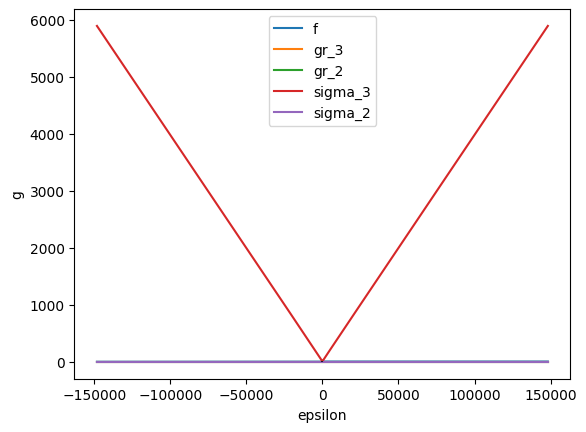

In [11]:
plt.plot(omega_grid**3, jnp.real(crt_f._trace(0)), label = 'f')
plt.plot(omega_grid**3, jnp.real(crt_gr._trace(3)), label = 'gr_3')
plt.plot(omega_grid**3, jnp.imag(crt_gr._trace(2)), label = 'gr_2')
#plt.plot(omega_grid, jnp.imag(crt_gr._trace(1)), label = 'gr_1')

#plt.plot(omega_grid, jnp.real(crt_gk._trace(3)), label = 'gk')
plt.plot(omega_grid**3, jnp.imag(scattering_sigma._trace(3)), label = 'sigma_3')
plt.plot(omega_grid**3, jnp.imag(scattering_sigma._trace(2)), label = 'sigma_2')

#plt.plot(omega_grid, kernel1, label = 'kernel1')
#plt.plot(omega_grid, 0.5 * kernel2 * jnp.real(crt_f._trace(0)), label = 'kernel2')
plt.vlines(crt_gap, -5, 5, colors = 'k', linestyles = 'dashed', alpha = 0.5)
plt.vlines(-crt_gap, -5, 5, colors = 'k', linestyles = 'dashed', alpha = 0.5)

#plt.plot(omega_grid, kernel1 - 0.5 * kernel2 * jnp.real(crt_f._trace(0)), label = 'integrand')
#plt.plot(omega_grid, kernel1 * jnp.real(crt_gr._trace(3)) - 0.5 * kernel2 * jnp.real(crt_gk._trace(3)), label = 'integrand')
print(jnp.sum(deps * (kernel1 - 0.5 * kernel2 * jnp.real(crt_f._trace(0))))/2/7/1.202056)
print(jnp.sum(deps * (kernel1 * jnp.real(crt_gr._trace(3)) - 0.5 * kernel2 * jnp.real(crt_gk._trace(3)) )/2/7/1.202056))
print(jnp.min(jnp.imag(scattering_sigma._trace(3))))
print(jnp.max(jnp.imag(scattering_sigma._trace(3)))/cutoff**3)

plt.xlabel('epsilon')
plt.ylabel('g')
#plt.xlim(-5,5)
#plt.ylim(-5,5)

plt.legend()

### Complete $\Sigma_r$ test

In [219]:
from self_energy_class import PhononScattering

temperature = 0.1
eta = 0.2
phonon_scattering = 0.000

In [220]:
cutoff = 30.0 * usadel.UsadelEvolution.get_bcs_ratio()
nw = 1501
  
# Define the fine grid
fine_nw = 200
fine_cutoff = 1.0* usadel.UsadelEvolution.get_bcs_ratio()

fine_nw = nw
fine_cutoff = cutoff

grid_parameters = {'omega_sampling': nw, 'cutoff': cutoff, 'time_duration': 1.0, 'time_sampling': 100}
system_parameters = {'critical_temperature': 1.0, 'current_maximum': 1.0, 'temperature': temperature, 'z_t/R_n': 50/170, 'eta': eta}
optimization_parameters = {'custom_jac': False, 'tol': 1e-3, 'maxiter': 200}
sigma_scatterings = {'Phonon': phonon_scattering} # {'Dynes': 0.0, 'Elastic': 0.0}
#sigma_scatterings = None

#* T_c in kelvin
T_c = 15.5 
#* write the current pulse in units of T_C. 
#*  FWHM = 1ps in 
t_pulse = 0.020 * T_c * 2 * jnp.pi
print('T pulse is ', t_pulse)
current_function_gaussian = lambda t: np.exp(-(t - 0)**2 * np.log(2)/(t_pulse)**2) 

my_usadel = usadel.UsadelEvolution(grid_parameters = grid_parameters, system_parameters = system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = sigma_scatterings)
print('Dynes eta is', my_usadel.eta)
print('cutoff is', my_usadel.cutoff)
omega_grid = my_usadel.w_arr

T pulse is  1.9477874452256718
Dynes eta is 0.23525405
cutoff is 52.916313


In [221]:
temp_list = jnp.array([temperature])
Q_list = jnp.array([0.0])

gap_list, current_list, g_list = comp.calculate_equilibrium_full(temp_list, grid_parameters, system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = sigma_scatterings,  Q_list = Q_list)


100%|██████████| 1/1 [00:00<00:00,  1.02it/s]


In [222]:
crt_gr =  g_list[0]
crt_gap = gap_list[0]
print('gap is', crt_gap[0])
crt_f = nmb.NambuTensor(my_usadel._thermal_occupation_numbers(temperature=temperature),0)

crt_sigma = PhononScattering(scattering_rate= 1.0, omega_arr= omega_grid, temperature = temperature)

scattering_sigma = crt_sigma._sigma_r(crt_gr, crt_f)

crt_gk = crt_gr @ crt_f + crt_f @ crt_gr._involution()

gap is 

1.5092247


0.0
1310.6611
-2.5360043


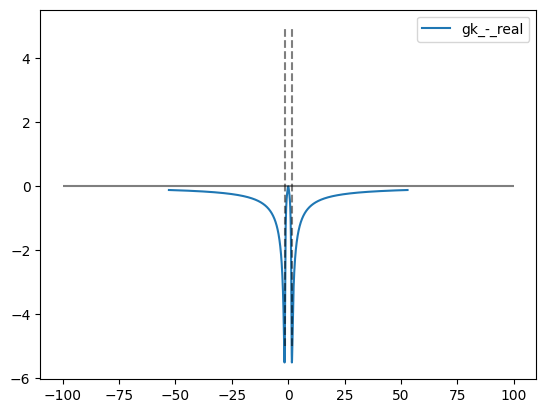

In [232]:
#plt.plot(omega_grid, jnp.real(crt_f._trace(0)), label = 'f')
#plt.plot(omega_grid, jnp.real(crt_gr._trace(3)), label = 'gr_3')
#plt.plot(omega_grid, jnp.real(crt_gr._trace(2)), label = 'gr_2')
#plt.plot(omega_grid, jnp.imag(crt_gk._trace('-')), label = 'gk_-_imag')
plt.plot(omega_grid, jnp.imag(crt_gk._trace(2)), label = 'gk_-_real')

#plt.plot(omega_grid, jnp.real(crt_gk._trace(3)), label = 'gk')
#plt.plot(omega_grid, jnp.imag(scattering_sigma._trace(3)), label = 'sigma_3')
#plt.plot(omega_grid, jnp.imag(scattering_sigma._trace(2)), label = 'sigma_2_im')
#plt.plot(omega_grid, jnp.real(scattering_sigma._trace(2)), label = 'sigma_2_re')

plt.hlines(0,-100,100, colors = 'k', alpha = 0.5)
plt.vlines(crt_gap, -5, 5, colors = 'k', linestyles = 'dashed', alpha = 0.5)
plt.vlines(-crt_gap, -5, 5, colors = 'k', linestyles = 'dashed', alpha = 0.5)

#plt.plot(omega_grid, kernel1 - 0.5 * kernel2 * jnp.real(crt_f._trace(0)), label = 'integrand')
#plt.plot(omega_grid, kernel1 * jnp.real(crt_gr._trace(3)) - 0.5 * kernel2 * jnp.real(crt_gk._trace(3)), label = 'integrand')
print(jnp.min(jnp.imag(scattering_sigma._trace(3))))
print(jnp.max(jnp.real(scattering_sigma._trace(2))))
print(jnp.max(jnp.imag(scattering_sigma._trace(2))))

kernel1 = omega_grid**2/(jnp.tanh(jnp.abs(omega_grid)/2/1.0/temperature + 1e-4))
kernel2 = (omega_grid**2 * jnp.sign(omega_grid))

#plt.plot(omega_grid, 1/temperature**2 * (kernel1 - 0.5 * kernel2 * jnp.real(crt_f._trace(0))) * jnp.imag(crt_gr._trace(2)), label = 'integrand')
#plt.plot(omega_grid, 1/temperature**2 * (kernel1 - 0.5 * kernel2 * jnp.real(crt_f._trace(0))) * jnp.real(crt_gr._trace(2)), label = 'integrand')
deps = jnp.diff(omega_grid,prepend= omega_grid[0])
#plt.xlabel('epsilon')
#plt.ylabel('g')hiws 
#plt.xlim(0,20)
#plt.ylim(-0.05,1)

plt.legend()
#plt.savefig('test_4.png')

In [233]:
epsilon_diff = -(omega_grid[None,:] - omega_grid[:,None])
#print(epsilon_diff)
#print(epsilon_diff.shape)
#print(epsilon_diff[500,:])
print(omega_grid[750])
print(epsilon_diff[750,:] + omega_grid)

-2.9057264e-07
[0. 0. 0. ... 0. 0. 0.]


## Directly comparing sigma code

-0.033749983
[-52.916313 -52.845757 -52.7752   ...  52.7752    52.845757  52.916313]
[-52.916313 -52.845757 -52.7752   ...  52.7752    52.845757  52.916313]
[2800.1362 2792.674  2785.2217 ... 2785.2217 2792.674  2800.1362]
[2800.1362 2792.674  2785.2217 ... 2785.2217 2792.674  2800.1362]
[-2800.1362 -2792.674  -2785.2217 ...  2785.2217  2792.674   2800.1362]
[-2800.1362 -2792.674  -2785.2217 ...  2785.2217  2792.674   2800.1362]
[-1.7914359e-05 -1.7962284e-05 -1.8010403e-05 ... -1.8009432e-05
 -1.7962284e-05 -1.7914359e-05]
[-1.7914359e-05 -1.7962284e-05 -1.8010403e-05 ... -1.8009432e-05
 -1.7962284e-05 -1.7914359e-05]
(-0.00024414062-42.70295j)
(-0-42.70295j)
(-0-42.70295j)
(-0.00048828125+0j)
0j
0j
(-0-42.70295j)
-42.70295j
-42.70295j
(42.70295+0j)
-42.67789j
last element -0.35547784j


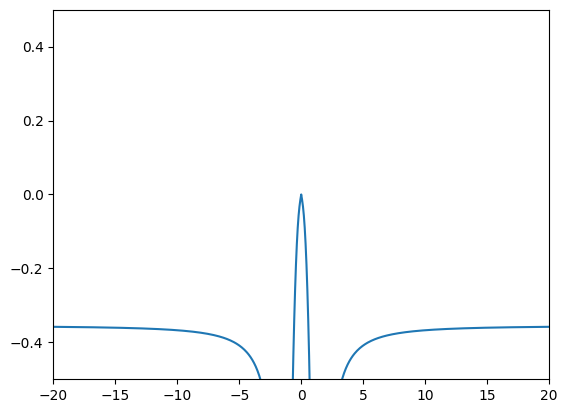

In [234]:
#* Option 1 
kernel1 = omega_grid**2/(jnp.tanh(jnp.abs(omega_grid)/2/1.0/temperature + 1e-6))
kernel2 = (omega_grid**2 * jnp.sign(omega_grid))

#plt.plot(omega_grid, 1/temperature**2 * (kernel1 - 0.5 * kernel2 * jnp.real(crt_f._trace(0))) * jnp.imag(crt_gr._trace(2)), label = 'integrand')
#plt.plot(omega_grid, 1/temperature**2 * (kernel1 - 0.5 * kernel2 * jnp.real(crt_f._trace(0))) * jnp.real(crt_gr._trace(2)), label = 'integrand')
deps = jnp.diff(omega_grid)
deps = jnp.append(deps[0], deps)
print(jnp.sum(deps * (kernel1 - 0.5 * kernel2 * jnp.real(crt_f._trace(0))) * jnp.real(crt_gr._trace(2))))


#* Option 2
epsilon_diff = (omega_grid[None,:] - omega_grid[:,None])

kernel1_eps = epsilon_diff**2/(jnp.tanh(jnp.abs(epsilon_diff/2/temperature) + 1e-4)) 
kernel2_eps = (epsilon_diff**2 * jnp.sign(epsilon_diff))


integrated_1 = -jnp.einsum('...i,ij -> ...j', (crt_gr*deps).data, kernel1_eps)
integrated_2 = jnp.einsum('...i,ij -> ...j', (crt_gk*deps).data, kernel2_eps)

res = nmb.NambuTensor((integrated_1 - 0.5 * integrated_2),None)


print('========')

print(omega_grid)
print(epsilon_diff[750,:])

print('========')

print(kernel1)
print(kernel1_eps[750,:])

print('========')

print(kernel2)
print(kernel2_eps[750,:])

print('========')
#plt.xlabel('epsilon')
#plt.ylabel('g')hiws 
print(jnp.real(crt_gr._trace(2) * deps))
print(jnp.real((crt_gr * deps)._trace(2)))

print('========')

print(integrated_1[0,1][750])
print(1j * jnp.sum((crt_gr._trace(2)*deps) * kernel1_eps[750,:])/2)
print(1j * jnp.sum(deps * kernel1 * (crt_gr._trace(2)))/2)

print('========')

print(integrated_2[0,1][750])
print(1j * jnp.sum((crt_gk._trace(2)*deps) * kernel2_eps[750,:])/2)
print(1j * jnp.sum(deps * kernel2 * (crt_gk._trace(2)))/2)
print('========')

print(1j * jnp.sum(deps * kernel1 * (crt_gr._trace(2)))/2 - 0.5 * 1j * jnp.sum(deps * kernel2 * (crt_gk._trace(2)))/2)
print(integrated_1[0,1][750] - 0.5 * integrated_2[0,1][750])
print(res.data[0,1][750])
print(res._trace(2)[750]/2)
print((scattering_sigma._trace(2))[750] * 7 * 1.2020566 * 4/2)

print('========')

plt.plot(omega_grid, jnp.imag(1j *( kernel1 * (crt_gr._trace(2)))/2 - 0.5 * 1j * ( kernel2 * (crt_gk._trace(2)))/2))

print('last element', (1j *( kernel1 * (crt_gr._trace(2)))/2 - 0.5 * 1j * ( kernel2 * (crt_gk._trace(2)))/2)[-1])
#plt.plot(omega_grid, kernel1)
#plt.plot(omega_grid, kernel2)


plt.xlim(-20,20)  
plt.ylim(-0.5,.5)   
#plt.hlines(0,-100,100, colors = 'k', alpha = 0.5)
plt.show()


In [235]:
#* Option 1 
kernel1 = omega_grid**2/(jnp.tanh(jnp.abs(omega_grid)/2/1.0/temperature + 1e-4))
kernel2 = (omega_grid**2 * jnp.sign(omega_grid))

#plt.plot(omega_grid, 1/temperature**2 * (kernel1 - 0.5 * kernel2 * jnp.real(crt_f._trace(0))) * jnp.imag(crt_gr._trace(2)), label = 'integrand')
#plt.plot(omega_grid, 1/temperature**2 * (kernel1 - 0.5 * kernel2 * jnp.real(crt_f._trace(0))) * jnp.real(crt_gr._trace(2)), label = 'integrand')
deps = jnp.diff(omega_grid,prepend= omega_grid[0])


#* Option 2
epsilon_diff = (omega_grid[None,:] - omega_grid[:,None])

kernel1_eps = epsilon_diff**2/(jnp.tanh(jnp.abs(epsilon_diff/2/temperature) + 1e-4)) 
kernel2_eps = (epsilon_diff**2 * jnp.sign(epsilon_diff))
  

integrated_1 = -jnp.einsum('...i,ij -> ...j', (crt_gr*deps).data, kernel1_eps)
integrated_2 = jnp.einsum('...i,ij -> ...j', (crt_gk*deps).data, kernel2_eps)

res = nmb.NambuTensor((integrated_1 - 0.5 * integrated_2),None)


print('========')

print(omega_grid)
print(epsilon_diff[750,:])

print('========')

print(kernel1)
print(kernel1_eps[750,:])

print('========')

print(kernel2)
print(kernel2_eps[750,:])

print('========')
#plt.xlabel('epsilon')
#plt.ylabel('g')hiws 
print(jnp.real(crt_gr._trace(3) * deps))
print(jnp.real((crt_gr * deps)._trace(3)))

print('========')

print(integrated_1[0,0][750])
print(1j * jnp.sum((crt_gr._trace(3)*deps) * kernel1_eps[750,:])/2)
print(1j * jnp.sum(deps * kernel1 * (crt_gr._trace(3)))/2)

print('========')

print(integrated_2[0,0][750])
print(1j * jnp.sum((crt_gk._trace(3)*deps) * kernel2_eps[750,:])/2)
print(1j * jnp.sum(deps * kernel2 * (crt_gk._trace(3)))/2)
print('========')

print(1j * jnp.sum(deps * kernel1 * (crt_gr._trace(3)))/2 - 0.5 * 1j * jnp.sum(deps * kernel2 * (crt_gk._trace(3)))/2)
print(integrated_1[0,0][750] - 0.5 * integrated_2[0,0][750])
print(res.data[0,0][750])
print(res._trace(3)[750]/2)
print((scattering_sigma._trace(3))[750] * 7 * 1.2020566 * 4/2)

[-52.916313 -52.845757 -52.7752   ...  52.7752    52.845757  52.916313]
[-52.916313 -52.845757 -52.7752   ...  52.7752    52.845757  52.916313]
[2800.1362 2792.674  2785.2217 ... 2785.2217 2792.674  2800.1362]
[2800.1362 2792.674  2785.2217 ... 2785.2217 2792.674  2800.1362]
[-2800.1362 -2792.674  -2785.2217 ...  2785.2217  2792.674   2800.1362]
[-2800.1362 -2792.674  -2785.2217 ...  2785.2217  2792.674   2800.1362]
[0.         0.14117086 0.14117101 ... 0.14116338 0.14117086 0.14117071]
[0.         0.14117086 0.14117101 ... 0.14116338 0.14117086 0.14117071]
(-98900.79+0.000715971j)
(0.00071549416+98900.78j)
(0.0007145405+98900.78j)
(-197801.56+0j)
197801.56j
197801.56j
(0.0007145405+0j)
(-0.0078125+0.000715971j)
(-0.0078125+0.000715971j)
(-0.0078125+0.000715971j)
(0.0007159714+0.007812504j)


In [37]:
gaps_out = []
gks_out = []
temperature = 0.2
eta = 0.05
phonon_scattering = 0.15

phonon_list = jnp.linspace(0.0, 0.2, 21, endpoint = True)

for phonon_scattering in phonon_list:
    cutoff = 10 * usadel.UsadelEvolution.get_bcs_ratio()
    nw = 1000

    # Define the fine grid
    fine_nw = 200
    fine_cutoff = 1.0* usadel.UsadelEvolution.get_bcs_ratio()

    fine_nw = nw
    fine_cutoff = cutoff

    grid_parameters = {'omega_sampling': nw, 'cutoff': cutoff, 'time_duration': 1.0, 'time_sampling': 100}
    system_parameters = {'critical_temperature': 1.0, 'current_maximum': 1.0, 'temperature': temperature, 'z_t/R_n': 50/170, 'eta': eta}
    optimization_parameters = {'custom_jac': False, 'tol': 1e-3, 'maxiter': 100}
    sigma_scatterings = {'Phonon': phonon_scattering} # {'Dynes': 0.0, 'Elastic': 0.0}
    #sigma_scatterings = None

    #* T_c in kelvin
    T_c = 15.5 
    #* write the current pulse in units of T_C. 
    #*  FWHM = 1ps in 
    t_pulse = 0.020 * T_c * 2 * jnp.pi
    #print('T pulse is ', t_pulse)
    current_function_gaussian = lambda t: np.exp(-(t - 0)**2 * np.log(2)/(t_pulse)**2) 

    my_usadel = usadel.UsadelEvolution(grid_parameters = grid_parameters, system_parameters = system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = sigma_scatterings)
    #print('Dynes eta is', my_usadel.eta)
    omega_grid = my_usadel.w_arr

    temp_list = jnp.array([temperature])
    Q_list = jnp.array([0.0])

    gap_list, current_list, g_list = comp.calculate_equilibrium_full(temp_list, grid_parameters, system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = sigma_scatterings,  Q_list = Q_list)

    crt_gr =  g_list[0]
    crt_gap = gap_list[0]
    print('gap is', crt_gap[0])
    crt_f = nmb.NambuTensor(my_usadel._thermal_occupation_numbers(temperature=temperature),0)

    crt_sigma = PhononScattering(scattering_rate= phonon_scattering, omega_arr= omega_grid, temperature = temperature)

    scattering_sigma = crt_sigma._sigma_r(crt_gr, crt_f)
    gaps_out += [crt_gap[0]]



  0%|          | 0/1 [00:01<?, ?it/s]


KeyboardInterrupt: 

Text(0, 0.5, '$\\Delta$')

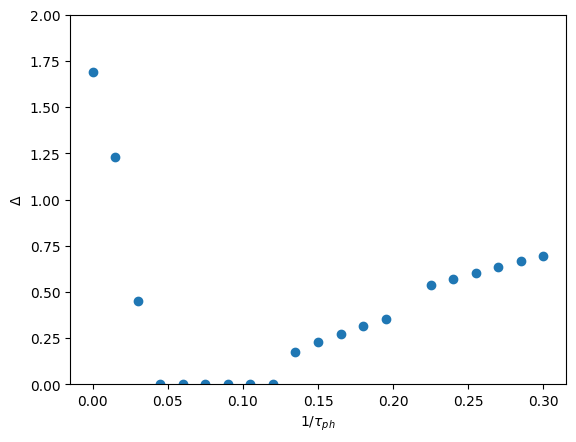

In [ ]:
plt.scatter(phonon_list, gaps_out)
plt.ylim(0,2)
plt.xlabel(r'$1/\tau_{ph}$')
plt.ylabel(r'$\Delta$')

In [ ]:
gaps_out = []


temperature = 0.2
eta = 0.05
phonon_scattering = phonon_list[1]

temperature_list = jnp.linspace(0.0, 1.2, 11, endpoint = True)

for temperature in temperature_list:
    cutoff = 10 * usadel.UsadelEvolution.get_bcs_ratio()
    nw = 1000

    # Define the fine grid
    fine_nw = 200
    fine_cutoff = 1.0* usadel.UsadelEvolution.get_bcs_ratio()

    fine_nw = nw
    fine_cutoff = cutoff

    grid_parameters = {'omega_sampling': nw, 'cutoff': cutoff, 'time_duration': 1.0, 'time_sampling': 100}
    system_parameters = {'critical_temperature': 1.0, 'current_maximum': 1.0, 'temperature': temperature, 'z_t/R_n': 50/170, 'eta': eta}
    optimization_parameters = {'custom_jac': False, 'tol': 1e-3, 'maxiter': 100}
    sigma_scatterings = {'Phonon': phonon_scattering} # {'Dynes': 0.0, 'Elastic': 0.0}
    #sigma_scatterings = None

    #* T_c in kelvin
    T_c = 15.5 
    #* write the current pulse in units of T_C. 
    #*  FWHM = 1ps in 
    t_pulse = 0.020 * T_c * 2 * jnp.pi
    #print('T pulse is ', t_pulse)
    current_function_gaussian = lambda t: np.exp(-(t - 0)**2 * np.log(2)/(t_pulse)**2) 

    my_usadel = usadel.UsadelEvolution(grid_parameters = grid_parameters, system_parameters = system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = sigma_scatterings)
    #print('Dynes eta is', my_usadel.eta)
    omega_grid = my_usadel.w_arr

    temp_list = jnp.array([temperature])
    Q_list = jnp.array([0.0])

    gap_list, current_list, g_list = comp.calculate_equilibrium_full(temp_list, grid_parameters, system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = sigma_scatterings,  Q_list = Q_list)

    crt_gr =  g_list[0]
    crt_gap = gap_list[0]
    print('gap is', crt_gap[0])
    crt_f = nmb.NambuTensor(my_usadel._thermal_occupation_numbers(temperature=temperature),0)

    crt_sigma = PhononScattering(scattering_rate= phonon_scattering, omega_arr= omega_grid, temperature = temperature)

    scattering_sigma = crt_sigma._sigma_r(crt_gr, crt_f)
    gaps_out += [crt_gap[0]]



100%|██████████| 1/1 [00:01<00:00,  1.19s/it]


gap is 1.331671


100%|██████████| 1/1 [00:00<00:00,  1.01it/s]


gap is 1.2342603


100%|██████████| 1/1 [00:01<00:00,  1.06s/it]


...

gap is 3.8322163e-17


100%|██████████| 1/1 [00:01<00:00,  1.37s/it]


gap is 7.8697264e-11


100%|██████████| 1/1 [00:01<00:00,  1.21s/it]


gap is 1.9563016e-07


Text(0, 0.5, '$\\Delta$')

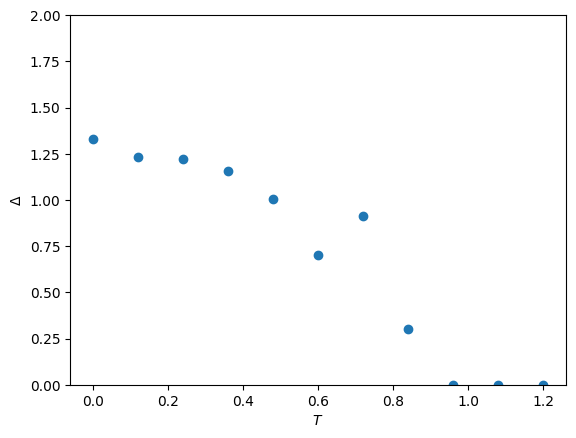

In [ ]:
plt.scatter(temperature_list, gaps_out)
plt.ylim(0,2)
plt.xlabel(r'$T$')
plt.ylabel(r'$\Delta$')